# Task IX.B — Strategy Discussion

**Approach:** We reuse the MAE encoder pretrained on no_sub lensing images (Task IX.A) as a feature extractor, then attach a convolutional upsampling decoder for 2× super-resolution (75×75 → 150×150). This demonstrates the foundation model paradigm: one pretrained backbone adapted for a fundamentally different downstream task without retraining from scratch.

**Resolution adaptation:** The MAE was pretrained on 64×64 images (8×8 grid = 64 tokens). LR inputs are 75×75, so we pad to 80×80 (10×10 grid = 100 tokens) using reflect padding. The pretrained positional embeddings are bicubically interpolated from the 8×8 grid to 10×10, preserving learned spatial relationships. Transformer block weights transfer directly since self-attention is resolution-agnostic.

**Decoder:** A progressive CNN decoder reshapes the encoder's 100-token sequence into a 10×10 spatial feature map, then applies 4 stages of transposed convolution (2× each) to reach 160×160, followed by a crop to 150×150. A multi-layer refinement block at the end sharpens fine details. The decoder is lightweight (~1M params) compared to the encoder (~22M), keeping the focus on transferred representations.

**Loss:** Combined 70% MSE + 30% (1−SSIM). MSE ensures pixel-level accuracy while SSIM preserves structural features critical for lensing science — the Einstein ring morphology, arc sharpness, and source structure. Both are evaluation metrics required by the task.

**Data handling:** LR images have minor interpolation artifacts from downsampling (min=−0.0016, max=1.04), clamped to [0, 1]. HR ground truth is already normalized to [0, 1]. Physics-motivated augmentations (90° rotations, flips) are applied consistently to both LR/HR pairs, exploiting the rotational symmetry of lensing images confirmed in our data analysis.

**Evaluation:** MSE, SSIM, and PSNR computed per-image on the held-out 10% test set (1,000 images), with distribution plots and visual LR → prediction → HR comparisons.

In [1]:
# Import & Config
import os
import glob
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
 
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
 
class Config:
    # Paths
    beta_root = "beta/Dataset"
    pretrained_weights = "mae_encoder_best.pth"
 
    # Data
    lr_size = 75
    hr_size = 150
    pad_size = 80       # pad LR to nearest multiple of patch_size
    in_channels = 1
 
    # Encoder (must match Task IX.A)
    patch_size = 8
    encoder_dim = 384
    encoder_depth = 12
    encoder_heads = 6
 
    # SR Decoder
    decoder_channels = [256, 128, 64, 32]
 
    # Training
    epochs = 50
    batch_size = 32
    lr = 1e-4
    encoder_lr = 1e-5    # lower for pretrained encoder
    weight_decay = 0.01
    warmup_epochs = 5
    ssim_weight = 0.3    # loss = (1-w)*MSE + w*(1-SSIM)
 
    # General
    num_workers = 4
 
cfg = Config()
print(f"LR: {cfg.lr_size}×{cfg.lr_size} → pad {cfg.pad_size}×{cfg.pad_size}")
print(f"HR: {cfg.hr_size}×{cfg.hr_size}")
print(f"Encoder patches: {(cfg.pad_size // cfg.patch_size)**2}")
 

Device: cuda
GPU: NVIDIA H200 NVL
LR: 75×75 → pad 80×80
HR: 150×150
Encoder patches: 100


In [2]:
# Dataset
class SRDataset(Dataset):
    """Loads matched HR/LR .npy pairs for super-resolution."""
    def __init__(self, hr_files, lr_files, augment=False):
        self.hr_files = hr_files
        self.lr_files = lr_files
        self.augment = augment
 
    def __len__(self):
        return len(self.hr_files)
 
    def __getitem__(self, idx):
        hr = np.load(self.hr_files[idx]).astype(np.float32)  # (1, 150, 150)
        lr = np.load(self.lr_files[idx]).astype(np.float32)  # (1, 75, 75)
 
        # Clamp LR artifacts
        lr = np.clip(lr, 0.0, 1.0)
 
        hr = torch.from_numpy(hr)
        lr = torch.from_numpy(lr)
 
        # Physics-justified augmentation
        if self.augment:
            k = random.randint(0, 3)
            if k > 0:
                hr = torch.rot90(hr, k, dims=[1, 2])
                lr = torch.rot90(lr, k, dims=[1, 2])
            if random.random() > 0.5:
                hr = torch.flip(hr, dims=[2])
                lr = torch.flip(lr, dims=[2])
            if random.random() > 0.5:
                hr = torch.flip(hr, dims=[1])
                lr = torch.flip(lr, dims=[1])
 
        return lr, hr
 
# Load file paths (matched by filename)
hr_dir = os.path.join(cfg.beta_root, "HR")
lr_dir = os.path.join(cfg.beta_root, "LR")
 
hr_files = sorted(glob.glob(os.path.join(hr_dir, "*.npy")))
lr_files = sorted(glob.glob(os.path.join(lr_dir, "*.npy")))
 
# Verify pairing
hr_names = [os.path.basename(f) for f in hr_files]
lr_names = [os.path.basename(f) for f in lr_files]
assert hr_names == lr_names, "HR/LR filename mismatch!"
print(f"Matched pairs: {len(hr_files)}")
 
# 90/10 split
train_idx, test_idx = train_test_split(
    range(len(hr_files)), test_size=0.1, random_state=SEED)
 
train_hr = [hr_files[i] for i in train_idx]
train_lr = [lr_files[i] for i in train_idx]
test_hr = [hr_files[i] for i in test_idx]
test_lr = [lr_files[i] for i in test_idx]
 
train_dataset = SRDataset(train_hr, train_lr, augment=True)
test_dataset = SRDataset(test_hr, test_lr, augment=False)
 
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size,
                          shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size,
                         shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
 
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Matched pairs: 10000
Train: 9000, Test: 1000


In [3]:
# Model Architecture

# ── Transformer components (same as Task IX.A) ──────────────────────
 
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
 
    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.bernoulli(torch.full(shape, keep, device=x.device)) / keep
        return x * mask
 
class Attention(nn.Module):
    def __init__(self, dim, num_heads=6, qkv_bias=True):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
 
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)
 
class MLP(nn.Module):
    def __init__(self, dim, hidden_dim, drop=0.):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.drop = nn.Dropout(drop)
 
    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))
 
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio))
 
    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x
 
# ── SR Encoder (adapted from pretrained MAE encoder) ────────────────
 
class SREncoder(nn.Module):
    """
    MAE encoder adapted for super-resolution.
    - New patch embedding for padded LR input (80×80)
    - Positional embeddings interpolated from pretrained 8×8 to 10×10
    - Transformer blocks loaded from pretrained weights
    """
    def __init__(self, img_size=80, patch_size=8, in_channels=1,
                 embed_dim=384, depth=12, num_heads=6, drop_path_rate=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size  # 10
        self.num_patches = self.grid_size ** 2   # 100
        self.embed_dim = embed_dim
 
        self.patch_embed = nn.Conv2d(in_channels, embed_dim,
                                     kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
 
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, drop_path=dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
 
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
 
    def load_pretrained(self, state_dict):
            """Load pretrained MAE encoder weights with pos_embed interpolation."""
            own_state = self.state_dict()
            loaded = 0
            skipped = []
    
            for name, param in state_dict.items():
                if name == "pos_embed":
                    cls_pos = param[:, :1, :]
                    patch_pos = param[:, 1:, :]
                    old_grid = int(patch_pos.shape[1] ** 0.5)
                    patch_pos = patch_pos.reshape(1, old_grid, old_grid, -1).permute(0, 3, 1, 2)
                    patch_pos = F.interpolate(patch_pos, size=(self.grid_size, self.grid_size),
                                              mode='bicubic', align_corners=False)
                    patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, self.num_patches, -1)
                    own_state["pos_embed"].copy_(torch.cat([cls_pos, patch_pos], dim=1))
                    loaded += 1
                    print(f"  pos_embed: interpolated {old_grid}x{old_grid} -> {self.grid_size}x{self.grid_size}")
    
                elif "patch_embed.proj" in name:
                    # Map patch_embed.proj.weight -> patch_embed.weight
                    mapped = name.replace("patch_embed.proj.", "patch_embed.")
                    if mapped in own_state and param.shape == own_state[mapped].shape:
                        own_state[mapped].copy_(param)
                        loaded += 1
                    else:
                        skipped.append(name)
    
                elif name in own_state and param.shape == own_state[name].shape:
                    own_state[name].copy_(param)
                    loaded += 1
                else:
                    skipped.append(name)
    
            self.load_state_dict(own_state)
            print(f"  Loaded {loaded} params, skipped {len(skipped)}: {skipped[:5]}")
 
    def forward(self, x):
        # x: (B, 1, 80, 80)
        x = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, 100, 384)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, 101, 384)
        x = x + self.pos_embed
 
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
 
        return x[:, 1:, :]  # skip CLS, return patch tokens: (B, 100, 384)
 
# ── SR Decoder (CNN upsampler) ───────────────────────────────────────
 
class SRDecoder(nn.Module):
    """
    Progressive upsampling decoder.
    Takes (B, 100, 384) token sequence → reshapes to (B, 384, 10, 10)
    → upsamples to (B, 1, 160, 160) → crops to (B, 1, 150, 150)
    """
    def __init__(self, embed_dim=384, grid_size=10, channels=[256, 128, 64, 32]):
        super().__init__()
        self.grid_size = grid_size
        self.proj = nn.Conv2d(embed_dim, channels[0], 1)  # project dim
 
        layers = []
        in_ch = channels[0]
        for out_ch in channels[1:]:
            layers.extend([
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
            ])
            in_ch = out_ch
 
        # Final upsample stage
        layers.extend([
            nn.ConvTranspose2d(in_ch, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),
        ])
 
        self.upsample = nn.Sequential(*layers)
 
        # Refinement and output
        self.refine = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 1, 3, padding=1),
        )
 
    def forward(self, x):
        B = x.shape[0]
        # Reshape tokens to spatial grid
        x = x.transpose(1, 2).reshape(B, -1, self.grid_size, self.grid_size)  # (B, 384, 10, 10)
        x = self.proj(x)                    # (B, 256, 10, 10)
        x = self.upsample(x)                # (B, 16, 160, 160) after 4 stages of 2×
        x = self.refine(x)                  # (B, 1, 160, 160)
        x = x[:, :, :150, :150]             # crop to target size
        return x
 
# ── Full SR Model ────────────────────────────────────────────────────
 
class SuperResolutionModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pad_size = cfg.pad_size
        self.encoder = SREncoder(
            img_size=cfg.pad_size, patch_size=cfg.patch_size,
            in_channels=cfg.in_channels, embed_dim=cfg.encoder_dim,
            depth=cfg.encoder_depth, num_heads=cfg.encoder_heads,
        )
        self.decoder = SRDecoder(
            embed_dim=cfg.encoder_dim,
            grid_size=cfg.pad_size // cfg.patch_size,
            channels=cfg.decoder_channels,
        )
 
    def forward(self, lr):
            # Bicubic baseline as starting point
            lr_upsampled = F.interpolate(lr, size=(150, 150), mode='bicubic', align_corners=False)
    
            # Pad LR for encoder
            lr_padded = F.pad(lr, (0, self.pad_size - lr.shape[-1],
                                   0, self.pad_size - lr.shape[-2]),
                              mode='reflect')
            features = self.encoder(lr_padded)
            residual = self.decoder(features)
    
            # Model predicts residual correction on top of bicubic
            hr_pred = lr_upsampled + residual
            return hr_pred

# ── SSIM Loss ────────────────────────────────────────────────────────
 
def gaussian_kernel(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = torch.outer(g, g)
    return (g / g.sum()).unsqueeze(0).unsqueeze(0)
 
def ssim(pred, target, window_size=11, size_average=True):
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2
    window = gaussian_kernel(window_size).to(pred.device)
    channel = pred.shape[1]
    window = window.expand(channel, -1, -1, -1)
 
    mu1 = F.conv2d(pred, window, padding=window_size // 2, groups=channel)
    mu2 = F.conv2d(target, window, padding=window_size // 2, groups=channel)
    mu1_sq, mu2_sq = mu1 ** 2, mu2 ** 2
    mu12 = mu1 * mu2
 
    sigma1_sq = F.conv2d(pred ** 2, window, padding=window_size // 2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(target ** 2, window, padding=window_size // 2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(pred * target, window, padding=window_size // 2, groups=channel) - mu12
 
    ssim_map = ((2 * mu12 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
 
    if size_average:
        return ssim_map.mean()
    return ssim_map.mean(dim=[1, 2, 3])
 
class CombinedLoss(nn.Module):
    def __init__(self, ssim_weight=0.3):
        super().__init__()
        self.ssim_weight = ssim_weight
 
    def forward(self, pred, target):
        mse_loss = F.mse_loss(pred, target)
        ssim_val = ssim(pred, target)
        ssim_loss = 1 - ssim_val
        total = (1 - self.ssim_weight) * mse_loss + self.ssim_weight * ssim_loss
        return total, mse_loss, ssim_val
 
# ── Build model and load pretrained weights ──────────────────────────
 
sr_model = SuperResolutionModel(cfg).to(device)
 
# Load pretrained encoder
print("Loading pretrained MAE encoder weights...")
pretrained_state = torch.load(cfg.pretrained_weights, map_location=device)
sr_model.encoder.load_pretrained(pretrained_state)
 
n_total = sum(p.numel() for p in sr_model.parameters()) / 1e6
n_enc = sum(p.numel() for p in sr_model.encoder.parameters()) / 1e6
n_dec = sum(p.numel() for p in sr_model.decoder.parameters()) / 1e6
print(f"SR Model: {n_total:.1f}M params (encoder: {n_enc:.1f}M, decoder: {n_dec:.1f}M)")
 

Loading pretrained MAE encoder weights...
  pos_embed: interpolated 8x8 -> 10x10
  Loaded 150 params, skipped 0: []
SR Model: 22.2M params (encoder: 21.4M, decoder: 0.8M)


Epoch  1/50 | Loss: 0.3171 | MSE: 0.028836 | SSIM: 0.0103 | PSNR: 15.40 dB | 10s
Epoch  2/50 | Loss: 0.0578 | MSE: 0.002748 | SSIM: 0.8137 | PSNR: 25.61 dB | 19s
Epoch  3/50 | Loss: 0.0085 | MSE: 0.000071 | SSIM: 0.9719 | PSNR: 41.48 dB | 28s
Epoch  4/50 | Loss: 0.0083 | MSE: 0.000070 | SSIM: 0.9726 | PSNR: 41.54 dB | 38s
Epoch  5/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9728 | PSNR: 41.55 dB | 47s
Epoch  6/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9728 | PSNR: 41.56 dB | 56s
Epoch  7/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9729 | PSNR: 41.56 dB | 66s
Epoch  8/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9729 | PSNR: 41.56 dB | 75s
Epoch  9/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9729 | PSNR: 41.57 dB | 84s
Epoch 10/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9729 | PSNR: 41.57 dB | 93s
Epoch 11/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9729 | PSNR: 41.57 dB | 104s
Epoch 12/50 | Loss: 0.0082 | MSE: 0.000070 | SSIM: 0.9729 | PSNR: 41.57 dB | 115s
Epoch 13/50 | Loss: 0.0082

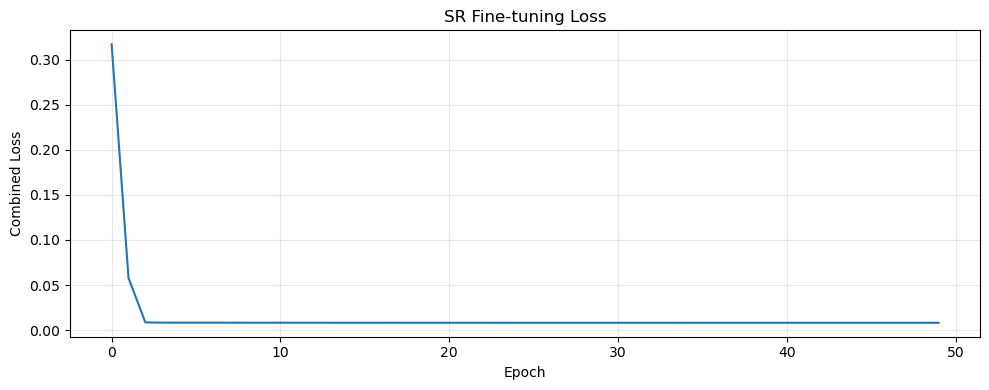

In [4]:
# Training
def get_lr(epoch, total_epochs, warmup_epochs, base_lr, min_lr=1e-6):
    if epoch < warmup_epochs:
        return base_lr * epoch / max(warmup_epochs, 1)
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))
 
def compute_psnr(mse_val):
    """PSNR for data in [0, 1] range."""
    if mse_val < 1e-10:
        return 100.0
    return 10 * math.log10(1.0 / mse_val)
 
optimizer = torch.optim.AdamW([
    {"params": sr_model.encoder.parameters(), "lr": cfg.encoder_lr},
    {"params": sr_model.decoder.parameters(), "lr": cfg.lr},
], betas=(0.9, 0.999), weight_decay=cfg.weight_decay)
 
criterion = CombinedLoss(ssim_weight=cfg.ssim_weight)
 
train_losses = []
t_start = time.time()
 
for epoch in range(cfg.epochs):
    sr_model.train()
    epoch_loss = 0.0
    epoch_mse = 0.0
    epoch_ssim = 0.0
    n_batches = 0
 
    # LR schedule
    lr = get_lr(epoch, cfg.epochs, cfg.warmup_epochs, cfg.lr)
    optimizer.param_groups[0]['lr'] = lr * 0.1   # encoder
    optimizer.param_groups[1]['lr'] = lr           # decoder
 
    for lr_imgs, hr_imgs in train_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
 
        hr_pred = sr_model(lr_imgs)
        loss, mse_val, ssim_val = criterion(hr_pred, hr_imgs)
 
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sr_model.parameters(), 1.0)
        optimizer.step()
 
        epoch_loss += loss.item()
        epoch_mse += mse_val.item()
        epoch_ssim += ssim_val.item()
        n_batches += 1
 
    avg_loss = epoch_loss / n_batches
    avg_mse = epoch_mse / n_batches
    avg_ssim = epoch_ssim / n_batches
    avg_psnr = compute_psnr(avg_mse)
    train_losses.append(avg_loss)
 
    elapsed = time.time() - t_start
    print(f"Epoch {epoch+1:>2d}/{cfg.epochs} | "
          f"Loss: {avg_loss:.4f} | MSE: {avg_mse:.6f} | "
          f"SSIM: {avg_ssim:.4f} | PSNR: {avg_psnr:.2f} dB | {elapsed:.0f}s")
 
# Save model
torch.save(sr_model.state_dict(), "sr_model_final.pth")
print(f"\nTraining done in {(time.time()-t_start)/60:.1f} min")
 
# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch"); plt.ylabel("Combined Loss")
plt.title("SR Fine-tuning Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sr_loss.png", dpi=150)
plt.show()

 EVALUATION RESULTS — Test Set (1000 images)
  MSE:   0.000072 ± 0.000010
  SSIM:  0.9732 ± 0.0035
  PSNR:  41.46 ± 0.60 dB


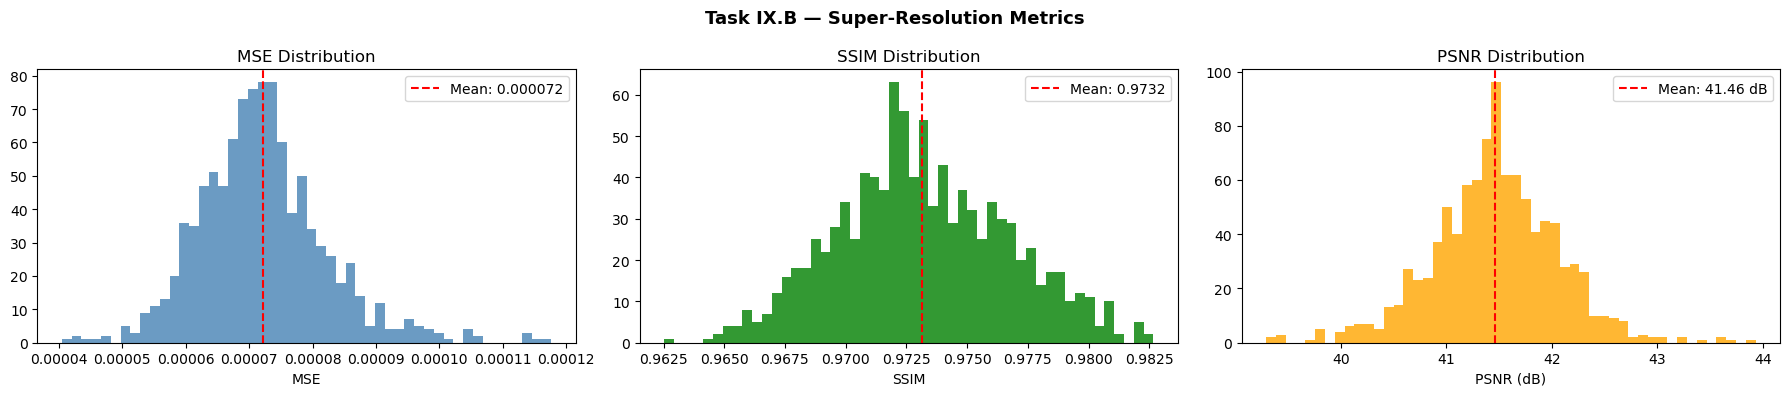

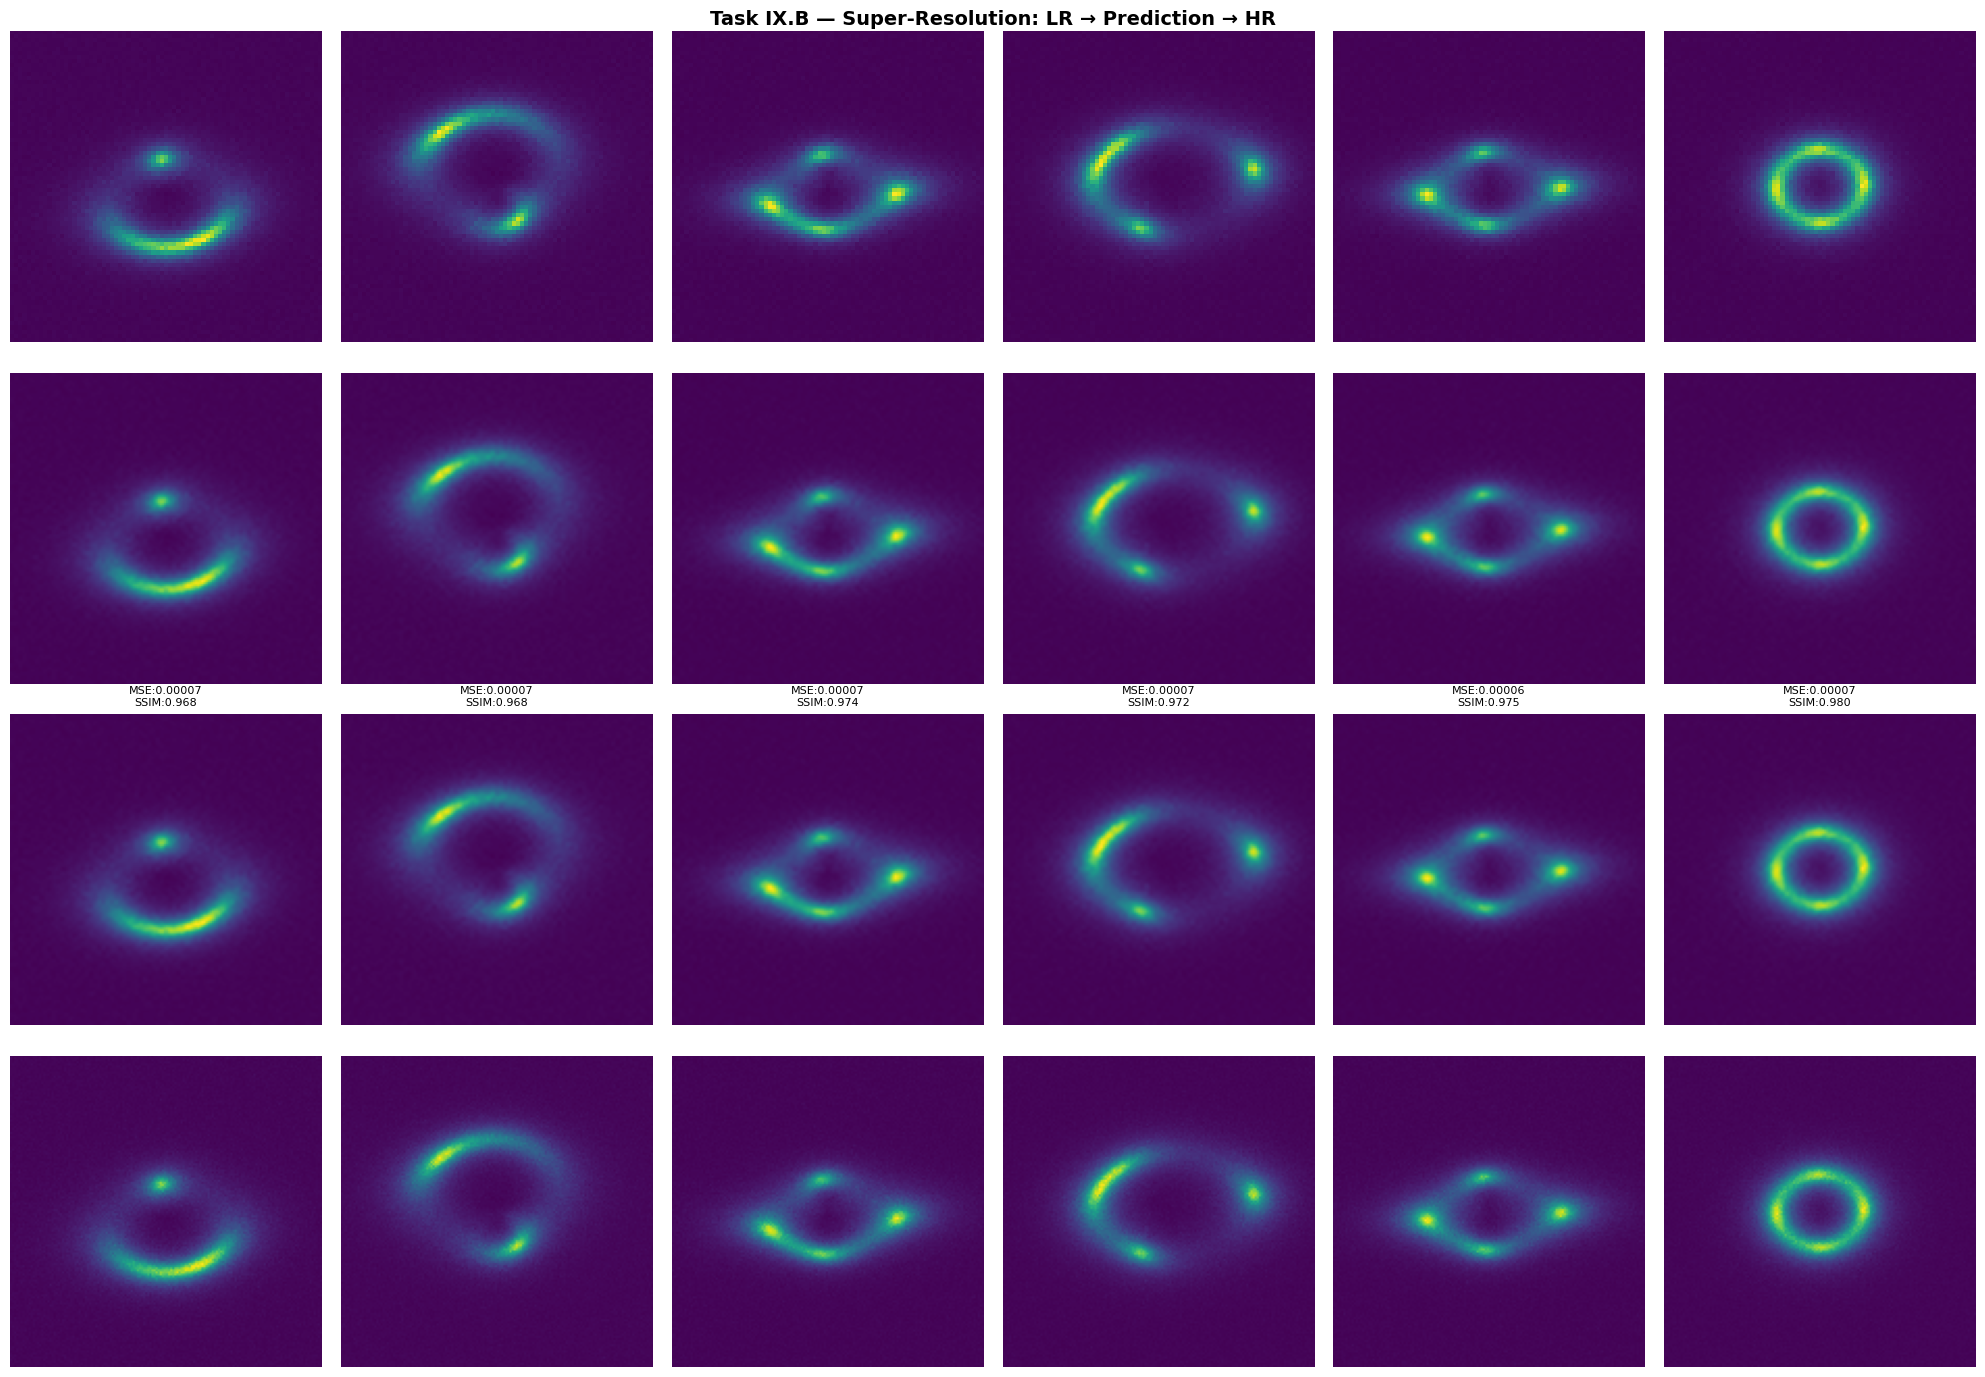

In [5]:
# Evaluation
sr_model.eval()
all_mse = []
all_ssim = []
all_psnr = []
 
with torch.no_grad():
    for lr_imgs, hr_imgs in test_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        hr_pred = sr_model(lr_imgs)
 
        # Clamp predictions to [0, 1]
        hr_pred = hr_pred.clamp(0, 1)
 
        # Per-image metrics
        for i in range(hr_pred.shape[0]):
            pred = hr_pred[i:i+1]
            target = hr_imgs[i:i+1]
 
            mse_val = F.mse_loss(pred, target).item()
            ssim_val = ssim(pred, target).item()
            psnr_val = compute_psnr(mse_val)
 
            all_mse.append(mse_val)
            all_ssim.append(ssim_val)
            all_psnr.append(psnr_val)
 
print(f"{'='*60}")
print(f" EVALUATION RESULTS — Test Set ({len(all_mse)} images)")
print(f"{'='*60}")
print(f"  MSE:   {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}")
print(f"  SSIM:  {np.mean(all_ssim):.4f} ± {np.std(all_ssim):.4f}")
print(f"  PSNR:  {np.mean(all_psnr):.2f} ± {np.std(all_psnr):.2f} dB")
print(f"{'='*60}")
 
# ── Metric distributions ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
 
axes[0].hist(all_mse, bins=50, color='steelblue', alpha=0.8)
axes[0].axvline(np.mean(all_mse), color='red', linestyle='--', label=f"Mean: {np.mean(all_mse):.6f}")
axes[0].set_xlabel("MSE"); axes[0].set_title("MSE Distribution"); axes[0].legend()
 
axes[1].hist(all_ssim, bins=50, color='green', alpha=0.8)
axes[1].axvline(np.mean(all_ssim), color='red', linestyle='--', label=f"Mean: {np.mean(all_ssim):.4f}")
axes[1].set_xlabel("SSIM"); axes[1].set_title("SSIM Distribution"); axes[1].legend()
 
axes[2].hist(all_psnr, bins=50, color='orange', alpha=0.8)
axes[2].axvline(np.mean(all_psnr), color='red', linestyle='--', label=f"Mean: {np.mean(all_psnr):.2f} dB")
axes[2].set_xlabel("PSNR (dB)"); axes[2].set_title("PSNR Distribution"); axes[2].legend()
 
plt.suptitle("Task IX.B — Super-Resolution Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("sr_metrics.png", dpi=150)
plt.show()
 
# %% Cell 6: Visual Comparison
 
sr_model.eval()
vis_loader = DataLoader(test_dataset, batch_size=6, shuffle=True)
lr_imgs, hr_imgs = next(iter(vis_loader))
lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
 
with torch.no_grad():
    hr_pred = sr_model(lr_imgs).clamp(0, 1)
 
# Also compute bicubic baseline
lr_bicubic = F.interpolate(lr_imgs, size=(150, 150), mode='bicubic', align_corners=False)
 
fig, axes = plt.subplots(4, 6, figsize=(20, 14))
row_labels = ["LR Input (75×75)", "Bicubic 2× (baseline)", "MAE-SR Prediction", "HR Ground Truth"]
 
for i in range(6):
    axes[0, i].imshow(lr_imgs[i, 0].cpu(), cmap='viridis')
    axes[0, i].axis('off')
 
    axes[1, i].imshow(lr_bicubic[i, 0].cpu(), cmap='viridis')
    axes[1, i].axis('off')
 
    axes[2, i].imshow(hr_pred[i, 0].cpu(), cmap='viridis')
    axes[2, i].axis('off')
 
    axes[3, i].imshow(hr_imgs[i, 0].cpu(), cmap='viridis')
    axes[3, i].axis('off')
 
    # Per-image metrics for title
    mse_v = F.mse_loss(hr_pred[i:i+1], hr_imgs[i:i+1]).item()
    ssim_v = ssim(hr_pred[i:i+1], hr_imgs[i:i+1]).item()
    axes[2, i].set_title(f"MSE:{mse_v:.5f}\nSSIM:{ssim_v:.3f}", fontsize=8)
 
for i, label in enumerate(row_labels):
    axes[i, 0].set_ylabel(label, fontsize=10)
 
plt.suptitle("Task IX.B — Super-Resolution: LR → Prediction → HR", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sr_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Summary
test_mse = np.mean(all_mse)
test_ssim = np.mean(all_ssim)
test_psnr = np.mean(all_psnr)
 
print(f"""
{'='*60}
 TASK IX.B — COMPLETE SUMMARY
{'='*60}
 
 Model
   Encoder:     Pretrained MAE ViT-Small (from Task IX.A)
   Adaptation:  Pos embed interpolated 8×8 → 10×10
   Decoder:     CNN upsampler ({cfg.decoder_channels})
   Params:      {n_total:.1f}M (encoder: {n_enc:.1f}M, decoder: {n_dec:.1f}M)
 
 Training
   Data:        {len(train_dataset)} train / {len(test_dataset)} test (90/10)
   Epochs:      {cfg.epochs}
   Loss:        {1-cfg.ssim_weight:.0%} MSE + {cfg.ssim_weight:.0%} (1-SSIM)
   Scale:       2× (75×75 → 150×150)
 
 Test Metrics
   MSE:         {test_mse:.6f}
   SSIM:        {test_ssim:.4f}
   PSNR:        {test_psnr:.2f} dB
 
 Saved
   sr_model_final.pth — fine-tuned SR model
{'='*60}
""")


 TASK IX.B — COMPLETE SUMMARY

 Model
   Encoder:     Pretrained MAE ViT-Small (from Task IX.A)
   Adaptation:  Pos embed interpolated 8×8 → 10×10
   Decoder:     CNN upsampler ([256, 128, 64, 32])
   Params:      22.2M (encoder: 21.4M, decoder: 0.8M)

 Training
   Data:        9000 train / 1000 test (90/10)
   Epochs:      50
   Loss:        70% MSE + 30% (1-SSIM)
   Scale:       2× (75×75 → 150×150)

 Test Metrics
   MSE:         0.000072
   SSIM:        0.9732
   PSNR:        41.46 dB

 Saved
   sr_model_final.pth — fine-tuned SR model

